# Semana 2: analisis exploratorio y reduccion dimensional
horizontal
Este cuaderno prepara la fase de la semana 2 del TFM sobre la tabla maestra de features. El objetivo es revisar la calidad de los datos, entender su estructura y proyectarlos con PCA para empezar a ver si aparecen separaciones por sistema, granja o vaca.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# BASE_DIR relativo (no ruta absoluta, criterio de calidad del TFM): funciona tanto si el
# notebook se ejecuta con cwd en la raiz del proyecto como si Jupyter lo abre con cwd en esta
# misma carpeta "experimentos".
BASE_DIR = Path.cwd()
if BASE_DIR.name == "experimentos":
    BASE_DIR = BASE_DIR.parent
MASTER_PATH = BASE_DIR / "datos" / "procesados" / "features" / "master_features.csv"

master = pd.read_csv(MASTER_PATH)
master["window_start"] = pd.to_datetime(master["window_start"], errors="coerce")

print("Shape:", master.shape)
print("Datasets:", master["dataset"].value_counts().to_dict())
print("Systems:", master["system"].value_counts().to_dict())
print("Missing values by column:")
display(master.isna().sum().loc[lambda s: s > 0].sort_values(ascending=False).to_frame(name="missing"))

Shape: (8274, 67)
Datasets: {'celso_horario': 4560, 'ruibal_horario': 2842, 'celso_diario': 562, 'valdillera': 310}
Systems: {'intensivo': 7964, 'extensivo': 310}
Missing values by column:


,missing
anomaly_rate,310
anomaly_count,310
graze_cv,70
walk_cv,50
eat_cv,19
ruminate_cv,19
steps_cv,18
graze_std,6
ruminate_std,6
eat_std,6


In [2]:
numeric_cols = master.select_dtypes(include="number").columns.tolist()
analysis_cols = [col for col in numeric_cols if col not in ["cow_id"]]
analysis_frame = master[analysis_cols].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(analysis_frame)
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(
    components,
    columns=["PC1", "PC2"],
    index=master.index,
)
pca_df = pd.concat([master[["dataset", "system", "cow_id", "window_start"]], pca_df], axis=1)

print("Varianza explicada:", pca.explained_variance_ratio_)
print("Varianza acumulada:", pca.explained_variance_ratio_.sum())

display(pca_df.head())

Varianza explicada: [0.59290175 0.06923425]
Varianza acumulada: 0.6621359951292802


,dataset,system,cow_id,window_start,PC1,PC2
0,celso_diario,intensivo,92,2024-04-08,20.020022,-5.080800
1,celso_diario,intensivo,92,2024-04-15,18.508812,-7.051157
2,celso_diario,intensivo,92,2024-04-22,19.905390,-7.456769
3,celso_diario,intensivo,92,2024-04-29,18.418941,-6.642233
4,celso_diario,intensivo,92,2024-05-06,16.841698,-6.736244


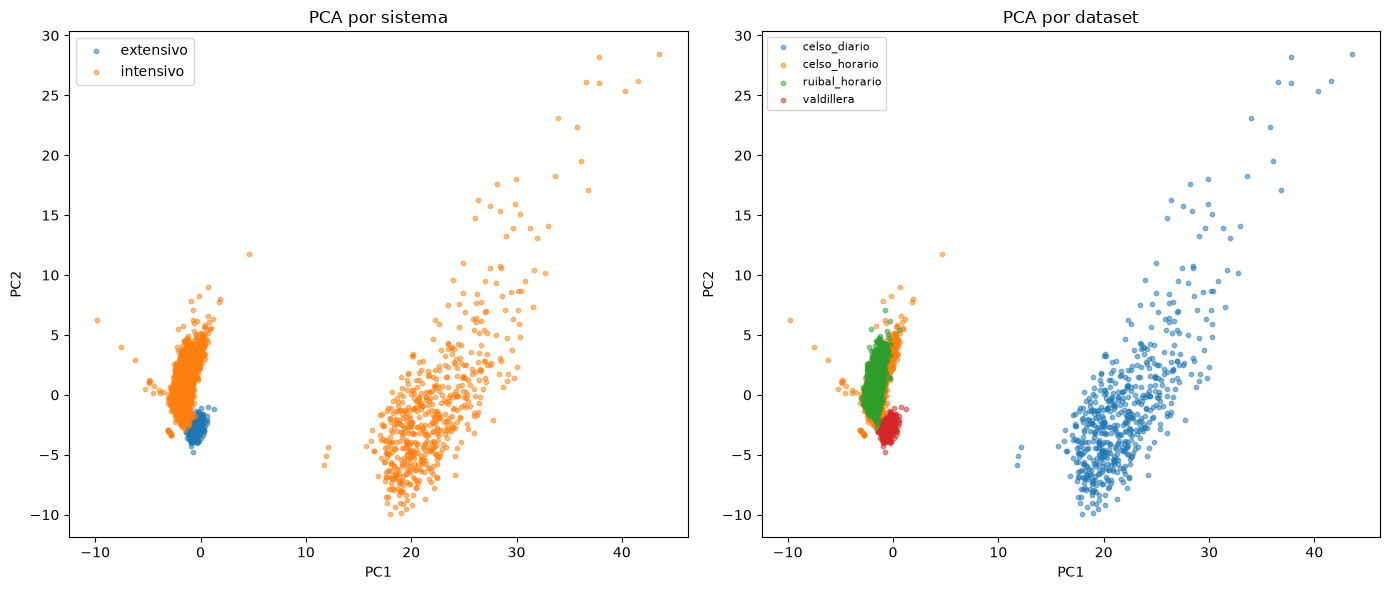

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for system_name, subset in pca_df.groupby("system"):
    axes[0].scatter(subset["PC1"], subset["PC2"], s=10, alpha=0.5, label=system_name)
axes[0].set_title("PCA por sistema")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

for dataset_name, subset in pca_df.groupby("dataset"):
    axes[1].scatter(subset["PC1"], subset["PC2"], s=10, alpha=0.5, label=dataset_name)
axes[1].set_title("PCA por dataset")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## PCA por resolución y por vaca

Antes de interpretar cualquier separación, conviene comprobar dos cosas: si diario y horario se comportan igual en PCA, y si la estructura del gráfico está dominada por vacas concretas.


Resolucion: horario
Datasets incluidos: {'celso_horario': 4560, 'ruibal_horario': 2842}
Sistemas incluidos: {'intensivo': 7402}
Varianza explicada: [0.19477057 0.18565118]
Varianza acumulada: 0.38042174179823196


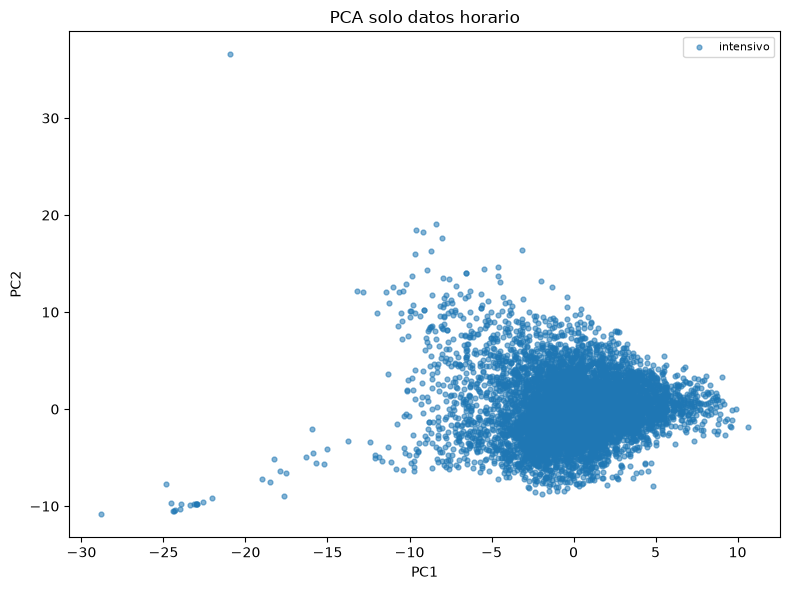


Resolucion: diario
Datasets incluidos: {'celso_diario': 562}
Sistemas incluidos: {'intensivo': 562}
Varianza explicada: [0.24921952 0.19081049]
Varianza acumulada: 0.44003000844967916


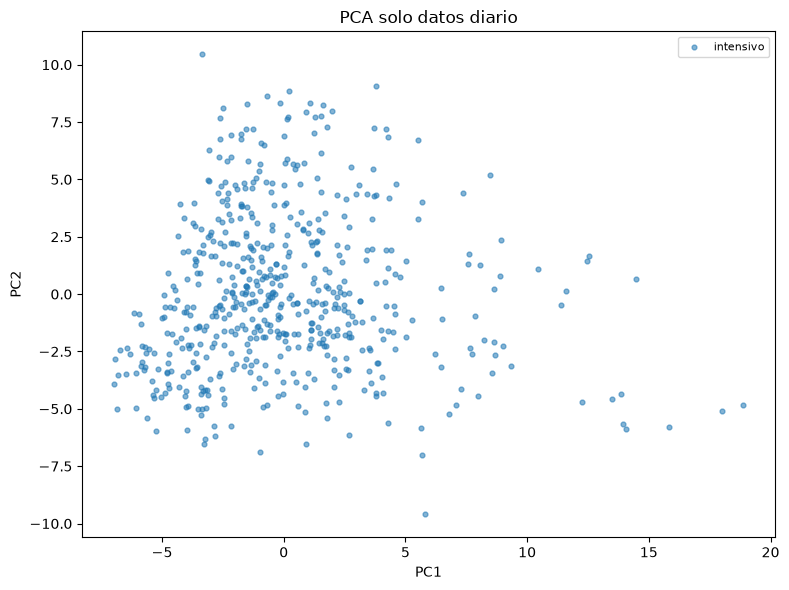

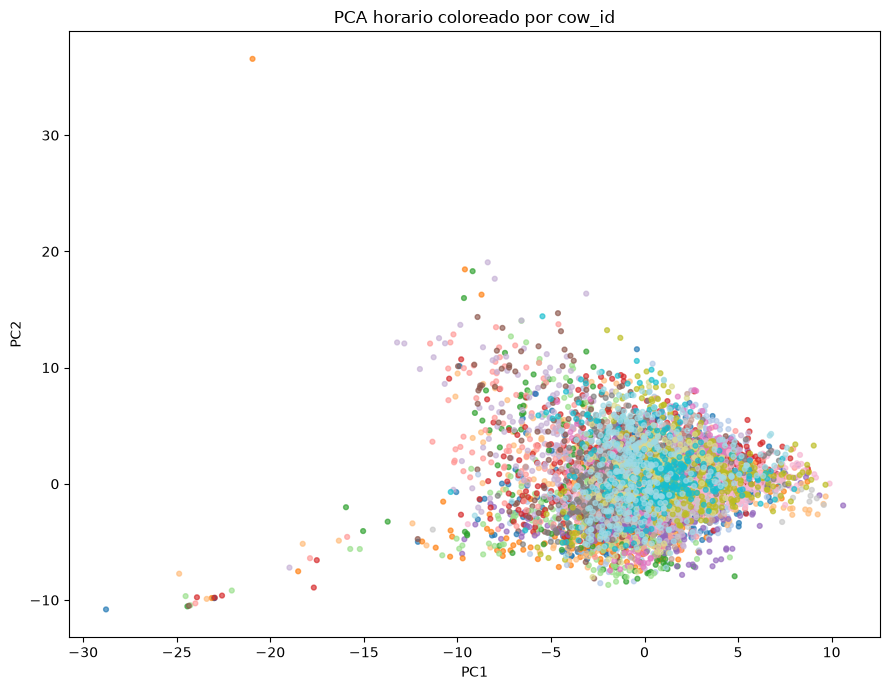

In [14]:
def run_pca_projection(frame):
    numeric_cols_local = frame.select_dtypes(include="number").columns.tolist()
    analysis_cols_local = [col for col in numeric_cols_local if col not in ["cow_id"]]
    analysis_frame_local = frame[analysis_cols_local].copy()

    imputer_local = SimpleImputer(strategy="median")
    scaler_local = StandardScaler()

    X_imputed_local = imputer_local.fit_transform(analysis_frame_local)
    X_scaled_local = scaler_local.fit_transform(X_imputed_local)

    pca_local = PCA(n_components=2, random_state=42)
    components_local = pca_local.fit_transform(X_scaled_local)

    pca_df_local = pd.DataFrame(components_local, columns=["PC1", "PC2"], index=frame.index)
    pca_df_local = pd.concat([frame[["dataset", "system", "cow_id", "window_start"]], pca_df_local], axis=1)
    return pca_local, pca_df_local

resolution_groups = {
    "horario": master[master["dataset"].str.contains("horario", case=False, na=False)].copy(),
    "diario": master[master["dataset"].str.contains("diario", case=False, na=False)].copy(),
}

resolution_results = {}
for resolution_name, subset in resolution_groups.items():
    if subset.empty:
        print(f"No hay datos para la resolucion {resolution_name}.")
        continue

    print(f"\nResolucion: {resolution_name}")
    print("Datasets incluidos:", subset["dataset"].value_counts().to_dict())
    print("Sistemas incluidos:", subset["system"].value_counts().to_dict())

    pca_resolution, pca_df_resolution = run_pca_projection(subset)
    resolution_results[resolution_name] = (pca_resolution, pca_df_resolution)
    print("Varianza explicada:", pca_resolution.explained_variance_ratio_)
    print("Varianza acumulada:", pca_resolution.explained_variance_ratio_.sum())

    fig, ax = plt.subplots(figsize=(8, 6))
    for system_name, group in pca_df_resolution.groupby("system"):
        ax.scatter(group["PC1"], group["PC2"], s=12, alpha=0.55, label=system_name)
    ax.set_title(f"PCA solo datos {resolution_name}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(eda_dir / f"pca_solo_{resolution_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

if "horario" in resolution_results:
    _, pca_df_horario = resolution_results["horario"]
    fig, ax = plt.subplots(figsize=(9, 7))
    scatter = ax.scatter(
        pca_df_horario["PC1"],
        pca_df_horario["PC2"],
        c=pd.Categorical(pca_df_horario["cow_id"]).codes,
        cmap="tab20",
        s=12,
        alpha=0.65,
    )
    ax.set_title("PCA horario coloreado por cow_id")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.tight_layout()
    plt.savefig(eda_dir / "pca_horario_coloreado_por_cow_id.png", dpi=150, bbox_inches="tight")
    plt.show()

## Comparacion intensivo diario vs extensivo diario

La comparacion principal del TFM debe hacerse con la misma resolucion temporal. Aqui se compara el conjunto diario de intensivo contra Valdillera, que tambien es diario.

Conteo por sistema en la comparacion diaria:


,n_rows
system,
intensivo,562
extensivo,310



Conteo por dataset en la comparacion diaria:


,n_rows
dataset,
celso_diario,562
valdillera,310



Conteo por sistema y dataset en la comparacion diaria:


,,n_rows
system,dataset,
extensivo,valdillera,310
intensivo,celso_diario,562



Varianza explicada (comparacion diaria): [0.53464999 0.11348328]
Varianza acumulada: 0.648133269210125


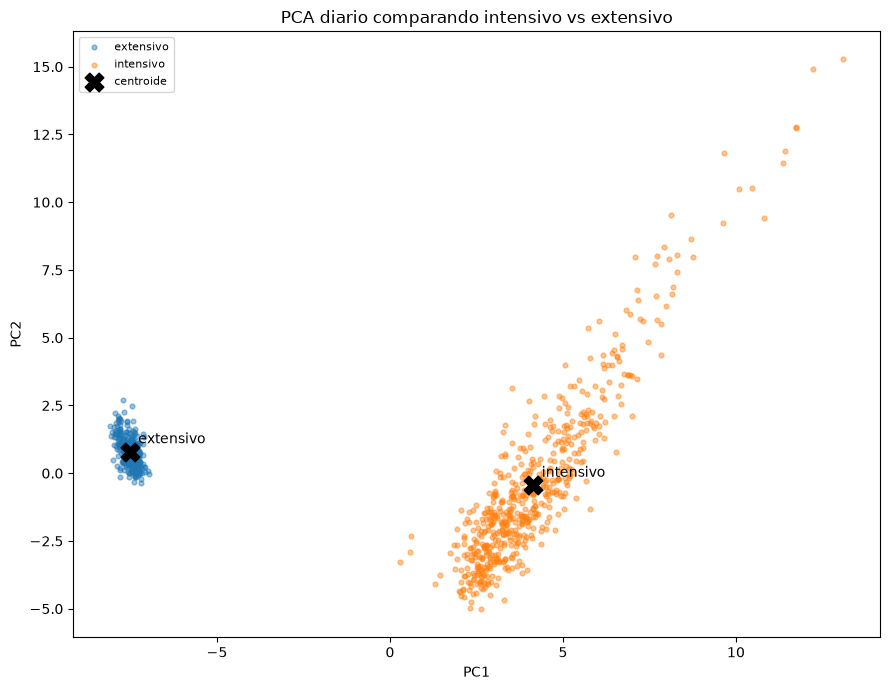


Media de variables clave por sistema en la comparacion diaria:


,media_extensivo,media_intensivo
ruminate_mean,19.957147,545.257776
eat_mean,11.757831,397.086572
graze_mean,12.359744,163.523923
rest_mean,13.415144,301.621846
walk_mean,1.983302,7.118673
steps_mean,302.459885,3048.116061
ratio_ruminate,0.335574,0.385491
ratio_eat,0.197672,0.280609
ratio_graze,0.207890,0.115660
ratio_rest,0.225512,0.213213


In [16]:
eda_dir = BASE_DIR / "resultados" / "eda"
eda_dir.mkdir(parents=True, exist_ok=True)

comparison_cols = [
    "ruminate_mean",
    "eat_mean",
    "graze_mean",
    "rest_mean",
    "walk_mean",
    "steps_mean",
    "ratio_ruminate",
    "ratio_eat",
    "ratio_graze",
    "ratio_rest",
    "ratio_walk",
]
comparison_cols = [col for col in comparison_cols if col in master.columns]

daily_comparison = master[master["dataset"].isin(["celso_diario", "valdillera"])].copy()

print("Conteo por sistema en la comparacion diaria:")
display(daily_comparison["system"].value_counts().to_frame(name="n_rows"))
print("\nConteo por dataset en la comparacion diaria:")
display(daily_comparison["dataset"].value_counts().to_frame(name="n_rows"))
print("\nConteo por sistema y dataset en la comparacion diaria:")
display(daily_comparison.groupby(["system", "dataset"]).size().to_frame(name="n_rows"))

comparison_pca = PCA(n_components=2, random_state=42)
comparison_frame = daily_comparison.select_dtypes(include="number").copy()
comparison_frame = comparison_frame.drop(columns=["cow_id"], errors="ignore")
comparison_imputed = SimpleImputer(strategy="median").fit_transform(comparison_frame)
comparison_scaled = StandardScaler().fit_transform(comparison_imputed)
comparison_components = comparison_pca.fit_transform(comparison_scaled)
comparison_df = pd.DataFrame(comparison_components, columns=["PC1", "PC2"], index=daily_comparison.index)
comparison_df = pd.concat([daily_comparison[["system", "dataset", "cow_id"]], comparison_df], axis=1)

print("\nVarianza explicada (comparacion diaria):", comparison_pca.explained_variance_ratio_)
print("Varianza acumulada:", comparison_pca.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(9, 7))
for system_name, subset in comparison_df.groupby("system"):
    ax.scatter(subset["PC1"], subset["PC2"], s=12, alpha=0.45, label=system_name)

centroids = comparison_df.groupby("system")[["PC1", "PC2"]].mean()
ax.scatter(centroids["PC1"], centroids["PC2"], s=180, marker="X", c="black", label="centroide")
for system_name, row in centroids.iterrows():
    ax.annotate(system_name, (row["PC1"], row["PC2"]), textcoords="offset points", xytext=(6, 6))

ax.set_title("PCA diario comparando intensivo vs extensivo")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(eda_dir / "pca_comparacion_diaria_sistema.png", dpi=150, bbox_inches="tight")
plt.show()

comparison_summary = daily_comparison.groupby("system")[comparison_cols].mean().T
comparison_summary.columns = [f"media_{col}" for col in comparison_summary.columns]
print("\nMedia de variables clave por sistema en la comparacion diaria:")
display(comparison_summary)

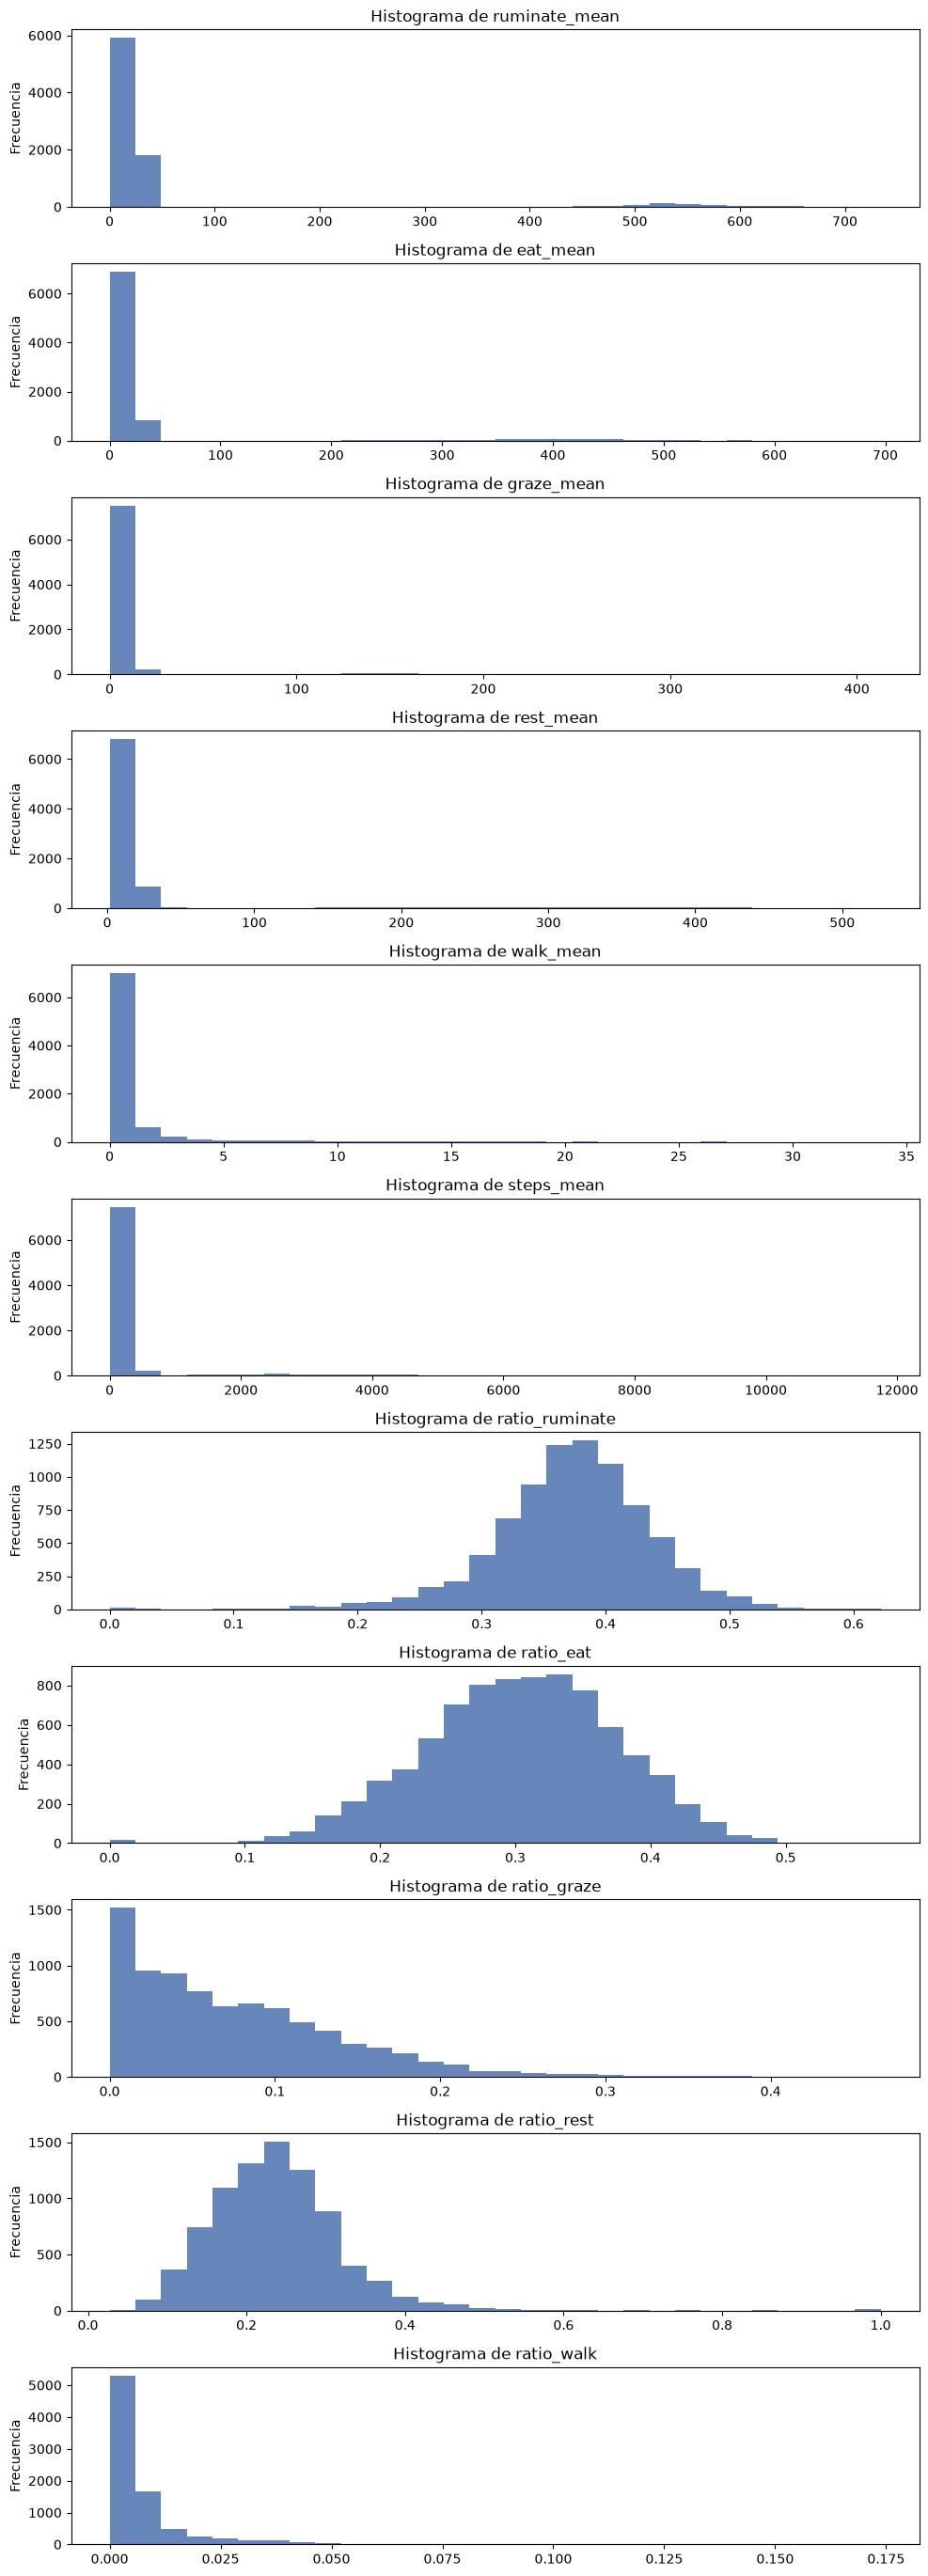

In [4]:
eda_dir = BASE_DIR / "resultados" / "eda"
eda_dir.mkdir(parents=True, exist_ok=True)

eda_features = [
    "ruminate_mean",
    "eat_mean",
    "graze_mean",
    "rest_mean",
    "walk_mean",
    "steps_mean",
    "ratio_ruminate",
    "ratio_eat",
    "ratio_graze",
    "ratio_rest",
    "ratio_walk",
]
eda_features = [feature for feature in eda_features if feature in master.columns]

fig, axes = plt.subplots(len(eda_features), 1, figsize=(10, 2.5 * len(eda_features)))
if len(eda_features) == 1:
    axes = [axes]

for axis, feature in zip(axes, eda_features):
    values = pd.to_numeric(master[feature], errors="coerce").dropna()
    axis.hist(values, bins=30, color="#4c72b0", alpha=0.85)
    axis.set_title(f"Histograma de {feature}")
    axis.set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig(eda_dir / "histogramas_variables_clave.png", dpi=150, bbox_inches="tight")
plt.show()

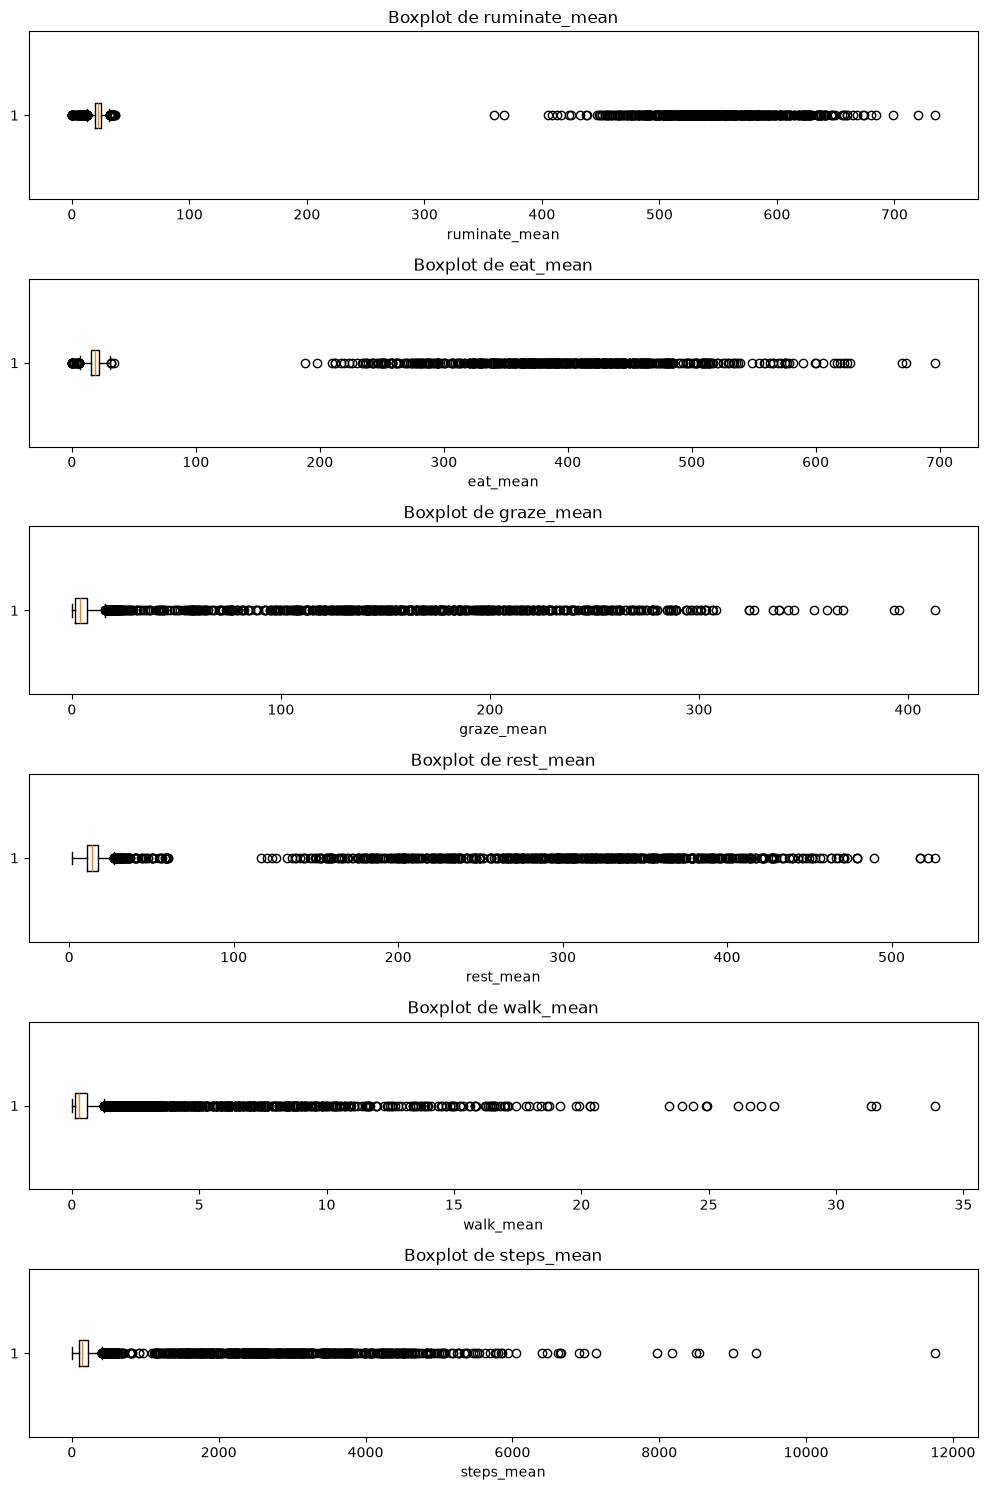

In [9]:
box_features = [
    "ruminate_mean",
    "eat_mean",
    "graze_mean",
    "rest_mean",
    "walk_mean",
    "steps_mean",
]
box_features = [feature for feature in box_features if feature in master.columns]

fig, axes = plt.subplots(len(box_features), 1, figsize=(10, 2.5 * len(box_features)), sharex=False)
if len(box_features) == 1:
    axes = [axes]

for axis, feature in zip(axes, box_features):
    values = pd.to_numeric(master[feature], errors="coerce").dropna()
    axis.boxplot(values, orientation="horizontal")
    axis.set_title(f"Boxplot de {feature}")
    axis.set_xlabel(feature)

plt.tight_layout()
plt.savefig(eda_dir / "boxplots_variables_clave.png", dpi=150, bbox_inches="tight")
plt.show()

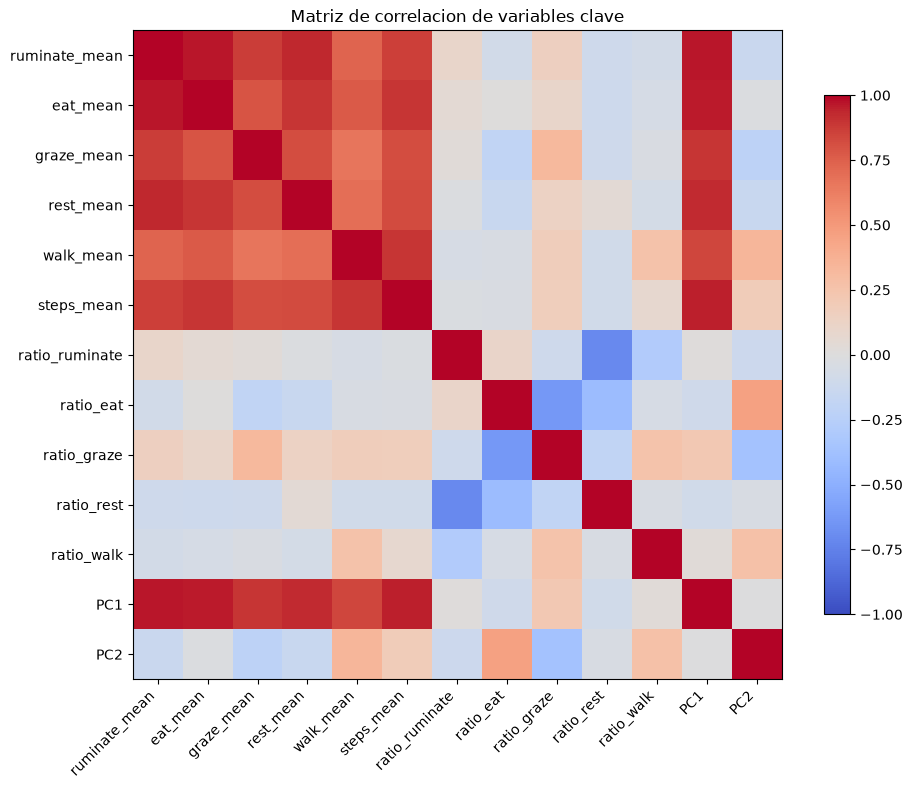

,ruminate_mean,eat_mean,graze_mean,rest_mean,walk_mean,steps_mean,ratio_ruminate,ratio_eat,ratio_graze,ratio_rest,ratio_walk,PC1,PC2
ruminate_mean,1.000000,0.967462,0.874329,0.929885,0.729334,0.865520,0.094394,-0.085463,0.153351,-0.107769,-0.074075,9.668872e-01,-1.345353e-01
eat_mean,0.967462,1.000000,0.793554,0.895091,0.767170,0.891882,0.054663,0.004325,0.099156,-0.112239,-0.058600,9.573320e-01,-2.097814e-02
graze_mean,0.874329,0.793554,1.000000,0.813010,0.656780,0.815162,0.027156,-0.193533,0.323267,-0.102944,-0.036148,8.920738e-01,-2.142550e-01
rest_mean,0.929885,0.895091,0.813010,1.000000,0.687841,0.824268,-0.021825,-0.142284,0.126454,0.043549,-0.068511,9.288086e-01,-1.454169e-01
walk_mean,0.729334,0.767170,0.656780,0.687841,1.000000,0.895130,-0.053193,-0.046417,0.179376,-0.086702,0.259653,8.436534e-01,3.375826e-01
steps_mean,0.865520,0.891882,0.815162,0.824268,0.895130,1.000000,-0.024717,-0.036945,0.171631,-0.089216,0.072214,9.465026e-01,1.798359e-01
ratio_ruminate,0.094394,0.054663,0.027156,-0.021825,-0.053193,-0.024717,1.000000,0.102253,-0.108529,-0.705184,-0.288996,1.210790e-02,-1.178346e-01
ratio_eat,-0.085463,0.004325,-0.193533,-0.142284,-0.046417,-0.036945,0.102253,1.000000,-0.627645,-0.407798,-0.053166,-9.532085e-02,4.581336e-01
ratio_graze,0.153351,0.099156,0.323267,0.126454,0.179376,0.171631,-0.108529,-0.627645,1.000000,-0.192762,0.252670,2.110790e-01,-3.624097e-01
ratio_rest,-0.107769,-0.112239,-0.102944,0.043549,-0.086702,-0.089216,-0.705184,-0.407798,-0.192762,1.000000,-0.043233,-9.364169e-02,-4.075454e-02


In [6]:
corr_features = [
    "ruminate_mean",
    "eat_mean",
    "graze_mean",
    "rest_mean",
    "walk_mean",
    "steps_mean",
    "ratio_ruminate",
    "ratio_eat",
    "ratio_graze",
    "ratio_rest",
    "ratio_walk",
    "PC1",
    "PC2",
]
corr_features = [feature for feature in corr_features if feature in pca_df.columns or feature in master.columns]
corr_source = pca_df.merge(master[["dataset", "system", "cow_id", "window_start"] + [col for col in corr_features if col in master.columns]], on=["dataset", "system", "cow_id", "window_start"], how="left")

corr_numeric = corr_source[[feature for feature in corr_features if feature in corr_source.columns]].copy()
corr_matrix = corr_numeric.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Matriz de correlacion de variables clave")
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(eda_dir / "correlacion_variables_clave.png", dpi=150, bbox_inches="tight")
plt.show()

corr_matrix

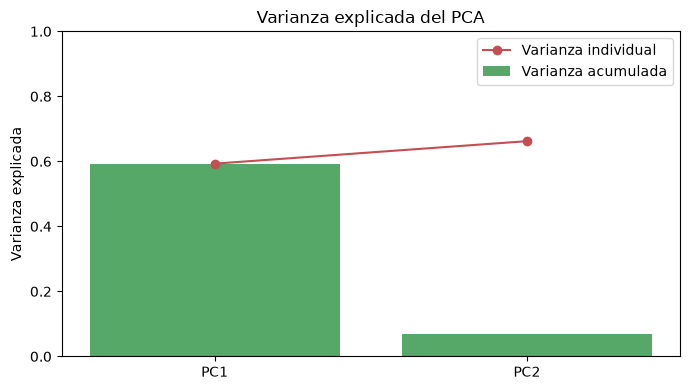

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
variance = pca.explained_variance_ratio_
components_labels = ["PC1", "PC2"]
ax.bar(components_labels, variance, color="#55a868")
ax.plot(components_labels, variance.cumsum(), marker="o", color="#c44e52")
ax.set_ylim(0, 1)
ax.set_ylabel("Varianza explicada")
ax.set_title("Varianza explicada del PCA")
ax.legend(["Varianza individual", "Varianza acumulada"], loc="best")
plt.tight_layout()
plt.savefig(eda_dir / "varianza_explicada_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
loadings = pd.DataFrame(pca.components_.T, index=analysis_cols, columns=["PC1", "PC2"])

print("Varianza explicada:", pca.explained_variance_ratio_)
print("Varianza acumulada:", pca.explained_variance_ratio_.sum())

for pc in ["PC1", "PC2"]:
    print(f"\nTop loadings absolutos de {pc}")
    display(loadings[pc].abs().sort_values(ascending=False).head(12).to_frame(name="abs_loading"))
    print(f"\nTop loadings con signo de {pc}")
    display(loadings[pc].sort_values(key=lambda s: s.abs(), ascending=False).head(12).to_frame(name="loading"))

print("\nVariables meta")
display(loadings.loc[[col for col in ["n_records", "n_missing", "anomaly_count", "anomaly_rate"] if col in loadings.index]])

Varianza explicada: [0.59290175 0.06923425]
Varianza acumulada: 0.6621359951292802

Top loadings absolutos de PC1


,abs_loading
ruminate_p90,0.158438
ruminate_max,0.158286
ruminate_median,0.158267
ruminate_mean,0.158203
ruminate_p10,0.157468
eat_p90,0.157036
eat_max,0.156640
eat_mean,0.156639
ruminate_min,0.156422
eat_median,0.155725



Top loadings con signo de PC1


,loading
ruminate_p90,0.158438
ruminate_max,0.158286
ruminate_median,0.158267
ruminate_mean,0.158203
ruminate_p10,0.157468
eat_p90,0.157036
eat_max,0.156640
eat_mean,0.156639
ruminate_min,0.156422
eat_median,0.155725



Top loadings absolutos de PC2


,abs_loading
walk_max,0.317266
steps_std,0.300997
steps_max,0.274978
walk_std,0.270547
steps_iqr,0.244006
anomaly_rate,0.220591
ratio_eat,0.219362
walk_p90,0.206777
steps_cv,0.190428
ratio_graze,0.173528



Top loadings con signo de PC2


,loading
walk_max,0.317266
steps_std,0.300997
steps_max,0.274978
walk_std,0.270547
steps_iqr,0.244006
anomaly_rate,0.220591
ratio_eat,0.219362
walk_p90,0.206777
steps_cv,0.190428
ratio_graze,-0.173528



Variables meta


,PC1,PC2
n_records,-0.114242,0.123339
n_missing,-0.035196,0.080540
anomaly_count,-0.010313,0.151378
anomaly_rate,0.026748,0.220591


In [11]:
print("Centroides por dataset")
display(pca_df.groupby("dataset")[["PC1", "PC2"]].mean().sort_values("PC1"))
print("\nCentroides por sistema")
display(pca_df.groupby("system")[["PC1", "PC2"]].mean().sort_values("PC1"))

Centroides por dataset


,PC1,PC2
dataset,,
ruibal_horario,-1.839794,0.498653
celso_horario,-1.561011,-0.007495
valdillera,-0.432513,-2.810377
celso_diario,22.208160,-0.910641



Centroides por sistema


,PC1,PC2
system,,
extensivo,-0.432513,-2.810377
intensivo,0.016836,0.109394
